# DeepSeek-Foundations · Workbook 01

### Linear Algebra — vectors, matrices, and the SVD that powers compression

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~60 min · **Prereqs:** high-school math, curiosity

> **Abstract.** We introduce a hands-on treatment of the linear algebra that underlies every large language model. We show that a token is a vector, a sentence is a matrix, and a batch of sentences is a tensor — and that the three operations that dominate LLM compute (embedding lookup, attention, the MLP) are all matrix products. The central object of the workbook is the matrix: a linear map, a set of independent directions (rank), a spectral object (eigendecomposition), and finally a compressible object (the singular value decomposition). We show that the singular-value spectrum is exactly the math behind the two tricks that make LLMs deployable: low-rank fine-tuning (LoRA) and quantization. Every section pairs tight theory with a runnable NumPy demo; the only dependencies are NumPy and matplotlib.

**How this fits the series.** This is Workbook 01 of the DeepSeek-Foundations curriculum. The map: [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb). The next step: [Workbook 02 — Calculus & Autodiff](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb).

**Contents.** 1. Vectors · 2. Matrices · 3. Tensor shapes · 4. Independence, basis, rank · 5. Eigendecomposition · 6. SVD · 7. Exercises & solutions.

## 1. Vectors: the atoms

Every piece of data that flows through an LLM is a vector: a token embedding, a hidden state, a row of a weight matrix. Formally, a vector is an element of $\mathbb{R}^n$ — an ordered list of $n$ real numbers, written as a column:

$$v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

Two operations define the vector-space structure, and they are all we ever use:

- **Addition:** $(a + b)_i = a_i + b_i$
- **Scalar multiplication:** $(c\,a)_i = c\,a_i$

The **norm** (length) and the **dot product** (inner product) of two vectors:

$$\|a\| = \sqrt{\sum_i a_i^2} = \sqrt{a \cdot a}, \qquad a \cdot b = \sum_i a_i b_i = \|a\|\,\|b\|\cos\theta$$

The **cosine similarity** $\cos\theta = \dfrac{a \cdot b}{\|a\|\,\|b\|}$ measures *alignment*: it is 1 for parallel vectors, 0 for orthogonal vectors, and $-1$ for anti-parallel vectors — and it ignores scale, because lengths cancel. That is why it is the workhorse of embedding spaces: "king" and "queen" embeddings point in similar directions, so their cosine similarity is high.

The **projection** of $a$ onto $b$ — the component of $a$ that points along $b$ — is the closest point to $a$ on the line spanned by $b$:

$$\mathrm{proj}_b(a) = \frac{a \cdot b}{\|b\|^2}\, b$$

**LLM connection.** Attention scores *are* dot products between query and key vectors; softmax then up-weights the keys with the largest alignment. Cosine similarity is how we check whether embeddings encode semantics at all.

In [1]:
# Demo 1.1 — embedding vectors: cosine similarity and projection
import numpy as np

king  = np.array([0.9, 0.4, 0.1, 0.2])   # hand-made 4-d "embeddings"
queen = np.array([0.8, 0.5, 0.2, 0.1])   # similar direction: related concept
rock  = np.array([-0.2, 0.3, 0.9, 0.6])  # far direction: unrelated concept

def cos_sim(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

print("cos(king, queen) =", round(float(cos_sim(king, queen)), 4))
print("cos(king, rock)  =", round(float(cos_sim(king, rock)), 4))

# projection of queen onto king: the part of queen pointing along king
proj = (queen @ king) / (king @ king) * king
print("proj of queen onto king =", np.round(proj, 4))
print("residual orthogonal to king:", abs((queen - proj) @ king) < 1e-12)

# scale invariance: doubling one vector does not change the cosine
print("cos(king, 2*queen) =", round(float(cos_sim(king, 2.0 * queen)), 4))

cos(king, queen) = 0.9804
cos(king, rock)  = 0.1303
proj of queen onto king = [0.8471 0.3765 0.0941 0.1882]
residual orthogonal to king: True
cos(king, 2*queen) = 0.9804


## 2. Matrices: linear maps

A matrix $A \in \mathbb{R}^{m \times n}$ *is* a linear map: it sends vectors $v \in \mathbb{R}^n$ to vectors $Av \in \mathbb{R}^m$ by

$$(Av)_i = \sum_{j=1}^{n} A_{ij}\, v_j$$

Linear maps preserve the vector-space structure — this is the defining property:

$$A(u + v) = Au + Av, \qquad A(c\,u) = c\,Au$$

Matrices multiply (this is *composition* of maps): $(AB)_{ik} = \sum_j A_{ij} B_{jk}$. The **transpose** swaps indices, $(A^\top)_{ij} = A_{ji}$, and the **identity** $I$ does nothing: $Iv = v$.

**The key insight.** The central object of a neural network is a layer

$$h = xW + b$$

— a matrix-vector product plus a bias. Strictly speaking this is an **affine** map: the linear part is $xW$, and the bias $b$ merely translates the output. Depth is composing such maps with nonlinearities in between; without the nonlinearities, any stack of layers would collapse into a single linear map (the product of the weight matrices). Everything a GPU does in an LLM forward pass is these operations, at enormous scale.

In [2]:
# Demo 2.1 — a matrix as a linear map; verify linearity numerically
import numpy as np

rng = np.random.default_rng(0)
A = rng.standard_normal((4, 4))
B = rng.standard_normal((4, 4))
u = rng.standard_normal(4)
v = rng.standard_normal(4)

print("A(u + v)  == Au + Av :", np.allclose(A @ (u + v), A @ u + A @ v))
print("A(3u)     == 3Au     :", np.allclose(A @ (3 * u), 3 * (A @ u)))
print("(A + B)v  == Av + Bv :", np.allclose((A + B) @ v, A @ v + B @ v))
print("I v       == v       :", np.allclose(np.eye(4) @ v, v))
print("max |(A+B)v - (Av + Bv)| =", np.max(np.abs((A + B) @ v - (A @ v + B @ v))))

# A layer is affine: linear part xW plus bias b. The bias breaks pure linearity.
W = rng.standard_normal((4, 4)); b = rng.standard_normal(4)
layer = lambda x: x @ W + b
print("layer(0) =", np.round(layer(np.zeros(4)), 4),
      "-> bias b != 0, so the layer is affine, not linear")

A(u + v)  == Au + Av : True
A(3u)     == 3Au     : True
(A + B)v  == Av + Bv : True
I v       == v       : True
max |(A+B)v - (Av + Bv)| = 2.220446049250313e-16
layer(0) = [ 0.4299  0.696  -1.1841 -0.6617] -> bias b != 0, so the layer is affine, not linear


## 3. Tensor shapes in deep learning

A **tensor** is just a multidimensional array. The three most important shapes in an LLM are $(B, T, C)$:

- $B$ — **batch**: how many sequences are processed at once (parallelism),
- $T$ — **sequence length** (context): how many tokens each sequence has,
- $C$ — **channels** / model width $d_{\text{model}}$: the size of the representation.

Where each dimension appears in a transformer:

| Tensor | Shape | Role |
|---|---|---|
| token embeddings | $(V, C)$ | lookup table: $V$ vocabulary tokens → $C$-dim vectors |
| input batch | $(B, T, C)$ | the embedded tokens after the lookup |
| attention scores | $(B, H, T, T)$ | $H$ heads × pairwise token alignment |
| MLP hidden | $(B, T, 4C)$ | the expand–contract block |
| weight matrices | $(C, C)$, $(C, 4C)$ | linear maps applied along the last axis |

Matrix multiplication in deep learning is *batched*: `X @ W` with $X \in \mathbb{R}^{B \times T \times C}$ and $W \in \mathbb{R}^{C \times D}$ contracts the last axis of $X$ with $W$, producing $(B, T, D)$ — the *same* linear map applied to every token of every sequence. That is the matmul a GPU is famous for.

In [3]:
# Demo 3.1 — tensor shapes of a (tiny) transformer, in NumPy
import numpy as np

rng = np.random.default_rng(0)
V, B, T, C = 32, 2, 8, 16          # vocab, batch, seq-len, model width

E = rng.standard_normal((V, C))    # (V, C) embedding table
X_idx = np.random.default_rng(1).integers(0, V, size=(B, T))
X = E[X_idx]                       # lookup -> (B, T, C)
print("embedding table E:", E.shape, "| input batch X:", X.shape)

W_q = rng.standard_normal((C, C)); W_k = rng.standard_normal((C, C))
Q = X @ W_q; K = X @ W_k
scores = Q @ K.transpose(0, 2, 1) / np.sqrt(C)   # (B, T, T) attention scores
print("Q, K:", Q.shape, "| attention scores:", scores.shape)

W1 = rng.standard_normal((C, 4 * C)); W2 = rng.standard_normal((4 * C, C))
h = X @ W1                          # (B, T, 4C) MLP expansion
out = h @ W2                        # (B, T, C) contraction
print("MLP hidden:", h.shape, "-> MLP out:", out.shape)

print("one batched matmul, all tokens: (B, T, C) @ (C, D) ->", (X @ W1).shape)

embedding table E: (32, 16) | input batch X: (2, 8, 16)
Q, K: (2, 8, 16) | attention scores: (2, 8, 8)
MLP hidden: (2, 8, 64) -> MLP out: (2, 8, 16)
one batched matmul, all tokens: (B, T, C) @ (C, D) -> (2, 8, 64)


## 4. Linear independence, basis, and rank

Vectors $v_1, \dots, v_k \in \mathbb{R}^n$ are **linearly independent** if the only way to write a zero combination

$$c_1 v_1 + \cdots + c_k v_k = 0$$

is with all coefficients $c_i = 0$. The set of all linear combinations — the **span** — is a subspace. A **basis** of $\mathbb{R}^n$ is any set of $n$ independent vectors: every vector in $\mathbb{R}^n$ has a *unique* representation in that basis. The immediate consequence: **you cannot fit more than $n$ independent vectors into $\mathbb{R}^n$**. Three vectors in 2D are always dependent — two directions already span the whole plane.

The **rank** of a matrix is the dimension of the space its columns span — equivalently, the number of independent columns (or rows). For $A \in \mathbb{R}^{m \times n}$,

$$\mathrm{rank}(A) \le \min(m, n)$$

A matrix is **rank-deficient** when its rank is strictly below $\min(m, n)$: it maps the whole space into a lower-dimensional subspace, so information is lost. Multiplication can only lower the rank, $\mathrm{rank}(AB) \le \min(\mathrm{rank}\,A, \mathrm{rank}\,B)$ — which is why a product of two skinny matrices is a cheap way to *parameterize* a low-rank matrix. Trained weight matrices are almost always *approximately* low-rank; LoRA exploits exactly this (Section 6).

In [4]:
# Demo 4.1 — rank: random vs rank-deficient, and 3 vectors in 2D
import numpy as np

rng = np.random.default_rng(0)

A_full = rng.standard_normal((5, 5))                # generic 5x5 -> full rank
A_low  = rng.standard_normal((5, 3)) @ rng.standard_normal((3, 5))  # rank <= 3
print("rank(random 5x5):       ", np.linalg.matrix_rank(A_full))
print("rank(5x3 @ 3x5 product):", np.linalg.matrix_rank(A_low))

# three vectors in 2D: stack them as columns of a 2x3 matrix -> rank <= 2
v = rng.standard_normal((2, 3))
print("rank of 3 vectors in R^2:", np.linalg.matrix_rank(v), "(max is 2)")

# find an explicit dependence: a nonzero c with v @ c == 0 (null vector of v)
c = np.linalg.svd(v)[2][-1]     # right singular vector of the smallest value
print("dependence coefficients c:", np.round(c, 4))
print("||v @ c|| =", round(float(np.linalg.norm(v @ c)), 12))

rank(random 5x5):        5
rank(5x3 @ 3x5 product): 3
rank of 3 vectors in R^2: 2 (max is 2)
dependence coefficients c: [ 0.3646 -0.8705  0.3306]
||v @ c|| = 0.0


## 5. Eigendecomposition

A nonzero vector $v$ is an **eigenvector** of $A$ with **eigenvalue** $\lambda$ if

$$A v = \lambda v$$

Multiplication by $A$ only stretches $v$ along its own direction — it never rotates it. Eigenvalues are the roots of the characteristic polynomial $\det(A - \lambda I) = 0$, and an $n \times n$ matrix has $n$ of them (counting multiplicity, over the complex numbers).

**Symmetric matrices** ($A = A^\top$) are special: their eigenvalues are all *real*, and their eigenvectors can be chosen *orthonormal*, so they diagonalize as

$$A = Q \Lambda Q^\top, \qquad Q^\top Q = I, \quad \Lambda = \mathrm{diag}(\lambda_1, \dots, \lambda_n)$$

This is why covariance matrices and Hessians — both symmetric by construction — admit clean spectral analysis: the eigenvalues measure how much the map stretches along each eigen-direction, and the eigenvectors give the directions themselves.

**Spectral intuition.** Expand the starting vector in the eigenbasis, $v_0 = \sum_i \alpha_i v_i$. Then

$$A^k v_0 = \sum_i \alpha_i \lambda_i^k\, v_i$$

If $|\lambda_1| > |\lambda_2| \ge \cdots \ge 0$, the term with the largest eigenvalue grows fastest, so repeated application drives the normalized vector toward the **top eigenvector** $v_1$. This is power iteration — and it is also why the singular-value spectrum (next section) is the right lens on *any* matrix, symmetric or not.

In [5]:
# Demo 5.1 — eigenvalues/eigenvectors, A v = lambda v, and power iteration
import numpy as np

rng = np.random.default_rng(0)
M = rng.standard_normal((4, 4))
A = M @ M.T                        # symmetric positive semi-definite: lam >= 0
lam, V = np.linalg.eigh(A)         # ascending eigenvalues; orthonormal columns
print("eigenvalues:", np.round(lam, 4))

# verify A v_i = lam_i v_i for every eigenvector
err = np.max(np.abs(A @ V - V * lam))
print("max |A v - lambda v| =", err)

# power iteration: A^k v0 / ||A^k v0|| -> top eigenvector direction
v0 = rng.standard_normal(4)
v = v0
for _ in range(60):
    v = A @ v
    v = v / np.linalg.norm(v)
top = V[:, -1]                     # eigenvector of the largest eigenvalue
print("|cos(A^k v0, top eigenvector)| =", round(abs(v @ top), 6),
      "-> 1 means aligned (sign is arbitrary)")

eigenvalues: [0.1013 1.3354 2.8512 9.2105]
max |A v - lambda v| = 1.7763568394002505e-15
|cos(A^k v0, top eigenvector)| = 1.0 -> 1 means aligned (sign is arbitrary)


## 6. The Singular Value Decomposition

Any matrix $A \in \mathbb{R}^{m \times n}$ factors as

$$A = U \Sigma V^\top$$

where $U \in \mathbb{R}^{m \times m}$ and $V \in \mathbb{R}^{n \times n}$ are orthogonal (their columns are the left and right **singular vectors**) and $\Sigma$ is $m \times n$ with nonnegative diagonal entries $\sigma_1 \ge \sigma_2 \ge \cdots \ge 0$ — the **singular values**. Equivalently, $A$ is a sum of rank-1 pieces:

$$A = \sum_{i=1}^{\min(m,n)} \sigma_i\, u_i v_i^\top$$

**Truncation is approximation.** Keep only the $r$ largest singular values:

$$A_r = \sum_{i=1}^{r} \sigma_i\, u_i v_i^\top$$

By the **Eckart–Young theorem**, $A_r$ is the best rank-$r$ approximation to $A$ in the Frobenius norm, and the error is exactly the energy in the discarded singular values:

$$\|A - A_r\|_F = \sqrt{\sum_{i > r} \sigma_i^2}, \qquad \|A\|_F = \sqrt{\sum_i \sigma_i^2}$$

So the singular-value spectrum tells you precisely how compressible a matrix is: if the values decay fast, a small $r$ captures almost everything.

**Why this powers LLM compression.** LoRA fine-tunes a *low-rank correction*: instead of updating a full weight matrix $W \in \mathbb{R}^{d \times d}$, it learns $W_0 + BA$ with $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times d}$, $r \ll d$ — the update lives in the low-rank subspace where the meaningful change happens. Quantization keeps only the important structure of the weights by storing each entry with fewer bits; the singular-value spectrum is the same math: it tells you how much structure a matrix really has, and what you can discard without losing it.

||A||_F^2 == sum(s^2): True
singular values (first 8): [13.286 12.604 12.1   11.366 11.057 10.525 10.258  9.766]
rank  1: measured 0.954909 | Eckart-Young 0.954909
rank  2: measured 0.912422 | Eckart-Young 0.912422
rank  5: measured 0.796129 | Eckart-Young 0.796129
rank 10: measured 0.625096 | Eckart-Young 0.625096
rank 20: measured 0.358089 | Eckart-Young 0.358089
rank 40: measured 0.000000 | Eckart-Young 0.000000


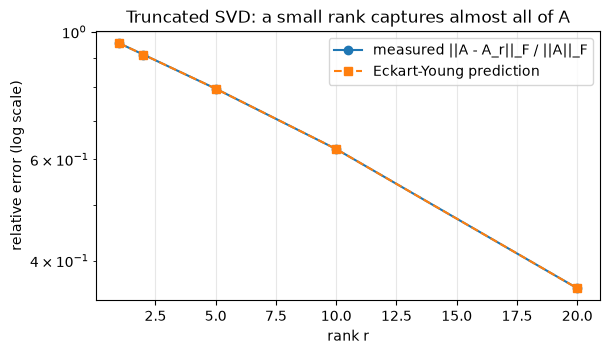

In [6]:
# Demo 6.1 — truncated SVD: reconstruction error vs rank (Eckart-Young)
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
A = rng.standard_normal((50, 40))
U, s, Vt = np.linalg.svd(A, full_matrices=False)   # thin SVD: U (50,40), Vt (40,40)
print("||A||_F^2 == sum(s^2):", np.allclose(np.sum(s ** 2), np.linalg.norm(A) ** 2))
print("singular values (first 8):", np.round(s[:8], 3))

ranks = [1, 2, 5, 10, 20, 40]
measured, theory = [], []
for r in ranks:
    A_r = (U[:, :r] * s[:r]) @ Vt[:r, :]                      # truncated reconstruction
    measured.append(np.linalg.norm(A - A_r) / np.linalg.norm(A))
    theory.append(np.sqrt(np.sum(s[r:] ** 2)) / np.sqrt(np.sum(s ** 2)))
    print(f"rank {r:2d}: measured {measured[-1]:.6f} | Eckart-Young {theory[-1]:.6f}")

# log plot (rank 40 is excluded: its error is exactly 0)
plt.figure(figsize=(6.5, 3.5))
plt.semilogy(ranks[:-1], measured[:-1], "o-", label="measured ||A - A_r||_F / ||A||_F")
plt.semilogy(ranks[:-1], theory[:-1], "s--", label="Eckart-Young prediction")
plt.xlabel("rank r"); plt.ylabel("relative error (log scale)"); plt.grid(alpha=0.3)
plt.legend(); plt.title("Truncated SVD: a small rank captures almost all of A")
plt.show()

## 7. Exercises

1. **Cosine similarity is scale-invariant.** Show numerically (or by algebra) that $\cos(a, b) = \cos(a, 5b)$ for any vectors $a, b$. *Hint: substitute $b' = 5b$ into $\frac{a \cdot b'}{\|a\|\,\|b'\|}$ and simplify — the factor 5 cancels.*

2. **A layer is affine, not linear.** For $h(x) = xW + b$ with $b \neq 0$, verify numerically that $h(u + v) \neq h(u) + h(v)$ in general, while the linear part $xW$ still satisfies linearity. *Hint: a linear map must send 0 to 0; check $h(0)$.*

3. **Why rank caps at the smaller dimension.** Show with `np.linalg.matrix_rank` that any 4 vectors in $\mathbb{R}^3$ are linearly dependent, and find an explicit nonzero combination summing to zero. *Hint: stack them as columns of a $3 \times 4$ matrix — rank $\le 3 < 4$, so a null vector exists; `np.linalg.svd(...)[2][-1]` finds it.*

4. **Symmetric spectra are real; rank deficiency shows up as a zero eigenvalue.** Build a random symmetric matrix and a random symmetric rank-deficient matrix, and compare their `np.linalg.eigvalsh` outputs. *Hint: rank equals the number of nonzero eigenvalues, so a rank-deficient symmetric matrix must have at least one zero eigenvalue.*

5. **The SVD of a rank-1 matrix.** Let $A = u v^\top$ with unit vectors $u, v$. Compute `np.linalg.svd(A, compute_uv=False)` and check there is exactly one nonzero singular value, equal to 1. *Hint: $A$ has rank 1, so only $\sigma_1$ survives; Eckart–Young then says the best rank-1 approximation is exact.*

## Solutions

1. $\cos(a, 5b) = \dfrac{a \cdot (5b)}{\|a\|\,\|5b\|} = \dfrac{5\,(a \cdot b)}{5\,\|a\|\,\|b\|} = \cos(a, b)$. Cosine similarity ignores scale by construction — lengths cancel.
2. $h(0) = 0W + b = b \neq 0$, so $h$ cannot be linear (a linear map must send $0$ to $0$). It is affine: $h(x) = xW + b$, and the linear part $xW$ is what the gradient flows through.
3. $\mathrm{rank} \le 3 < 4$: four columns in $\mathbb{R}^3$ cannot be independent. The code below finds the explicit dependence.
4. `eigvalsh` on a symmetric matrix returns only real eigenvalues; and since rank equals the number of nonzero eigenvalues, a rank-deficient symmetric matrix has a zero eigenvalue.
5. $\mathrm{rank}(A) = 1$ means exactly one nonzero singular value; because $u$ and $v$ are unit vectors it is $\sigma_1 = 1$, and $A_1 = A$ exactly.

In [7]:
# Solutions — run each check; all should print True / matching values
import numpy as np

rng = np.random.default_rng(42)

# 1. cosine similarity ignores scale
a, b = rng.standard_normal(5), rng.standard_normal(5)
cs = lambda x, y: x @ y / (np.linalg.norm(x) * np.linalg.norm(y))
print("1) cos(a, b) == cos(a, 5b):", np.allclose(cs(a, b), cs(a, 5 * b)))

# 2. a layer with bias is affine, not linear
W, bias = rng.standard_normal((3, 3)), rng.standard_normal(3)
layer = lambda x: x @ W + bias
u, v = rng.standard_normal(3), rng.standard_normal(3)
print("2) layer(0) == 0:", np.allclose(layer(np.zeros(3)), 0), "-> False: affine, not linear")
print("   layer(u+v) == layer(u) + layer(v):", np.allclose(layer(u + v), layer(u) + layer(v)))

# 3. four vectors in R^3 are always dependent (rank <= 3)
cols = rng.standard_normal((3, 4))
dep = np.linalg.svd(cols)[2][-1]      # null vector: a nonzero combination -> 0
print("3) rank of 4 vectors in R^3:", np.linalg.matrix_rank(cols),
      "| ||cols @ c|| =", round(float(np.linalg.norm(cols @ dep)), 12))

# 4. symmetric -> real eigenvalues; rank-deficient -> a zero eigenvalue
S = rng.standard_normal((4, 4)); S = S + S.T
print("4) symmetric eigenvalues:", np.round(np.linalg.eigvalsh(S), 4))
X = rng.standard_normal((3, 2))
Z = X @ X.T                           # symmetric, rank <= 2
print("   rank-deficient symmetric eigenvalues:", np.round(np.linalg.eigvalsh(Z), 4),
      "-> contains 0")

# 5. SVD of a rank-1 matrix A = u v^T
u = np.array([1.0, 0.0, 0.0]); v = np.array([0.0, 1.0, 0.0])
A1 = np.outer(u, v)
print("5) singular values of u v^T:", np.round(np.linalg.svd(A1, compute_uv=False), 6),
      "-> exactly one nonzero, = 1")

1) cos(a, b) == cos(a, 5b): True
2) layer(0) == 0: False -> False: affine, not linear
   layer(u+v) == layer(u) + layer(v): False
3) rank of 4 vectors in R^3: 3 | ||cols @ c|| = 0.0
4) symmetric eigenvalues: [-1.7567 -0.5408  1.2639  2.2579]
   rank-deficient symmetric eigenvalues: [-0.     2.76   4.182] -> contains 0
5) singular values of u v^T: [1. 0. 0.] -> exactly one nonzero, = 1


**You have completed Workbook 01 — Linear Algebra.** The matrix machinery you now hold — linear maps, rank, spectra, and the SVD — is the substrate of every model you will meet next.

**Next →** [Workbook 02 — Calculus & Autodiff](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb)

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)